# 02 - Business Rules: definicion de `ChurnType`

Objetivo: disenar una regla de negocio explicable para clasificar a cada cliente en `softchurn` / `midchurn` / `hardchurn` **segun el impacto economico que tendria su abandono**, sin usar `Exited`.

Este notebook es un prototipo. La version definitiva de la funcion se implementara en `src/business/churn_impact.py` con tests en `tests/test_business.py`.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/churn.csv')
df.shape

(10000, 14)

## 1. Que representa `ChurnType`

`ChurnType` NO es la probabilidad de que el cliente abandone (eso lo hace XGBoost). `ChurnType` responde a: **si este cliente abandonase, ¿cuanto le cuesta al banco?**

Debe cumplir:
- Calculable **antes** de saber si el cliente abandona (no usa `Exited`).
- Basado en variables de **valor del cliente**, no de **riesgo de abandono**.
- Explicable a negocio (nada de cajas negras).

## 2. Variables elegidas y por que

| Variable | Rol en el valor economico | Peso |
|---|---|---|
| `Balance` | Saldo depositado que el banco pierde directamente si el cliente se va | 0.40 |
| `EstimatedSalary` | Proxy de potencial de negocio futuro (creditos, cross-selling) | 0.30 |
| `NumOfProducts` | Ingresos recurrentes: mas productos contratados = mas ingresos en riesgo | 0.20 |
| `Tenure` | Antigüedad: proxy del coste de adquisicion ya amortizado y de la relacion construida | 0.10 |

**Variables deliberadamente excluidas** de este calculo (aunque son buenas para XGBoost):
- `Age`, `CreditScore`, `Geography`, `IsActiveMember`, `HasCrCard`: son senales de **riesgo de abandono**, no de **valor economico del cliente**. Mezclarlas aqui duplicaria informacion que ya captura XGBoost y difuminaria la separacion conceptual riesgo/impacto que exige el proyecto.

## 3. Construcción del `value_score` mediante reglas de negocio

El `value_score` se construye mediante reglas de negocio basadas en condiciones y umbrales fijos. Este enfoque permite asignar a cada cliente una puntuación económica determinista e interpretable, sin que su valor dependa de la distribución relativa del resto de clientes.

Las variables utilizadas y su peso dentro del `value_score` son:

* `Balance`: 40%
* `EstimatedSalary`: 30%
* `NumOfProducts`: 20%
* `Tenure`: 10%

Cada variable se divide en diferentes intervalos mediante condiciones predefinidas y se asigna una puntuación entre `0.25` y `1.00` según el nivel de valor del cliente. Posteriormente, las puntuaciones individuales se combinan mediante una suma ponderada:

```text
value_score =
    0.40 · balance_score +
    0.30 · salary_score +
    0.20 · products_score +
    0.10 · tenure_score
```

Este método hace que el `value_score` sea determinista, interpretable y estable, ya que el resultado depende exclusivamente de unas reglas de negocio previamente definidas y no de la composición o distribución de la cartera de clientes.

In [9]:
WEIGHTS = {'balance': 0.40, 'salary': 0.30, 'products': 0.20, 'tenure': 0.10}

def compute_value_score(df):
    # Cada variable se traduce a un score discreto (0.25/0.50/0.75/1.0)
    # segun bandas de negocio fijas, en vez de percentiles relativos a la
    # cartera. Ventaja: los cortes no se mueven si la cartera cambia, y son
    # auditables/explicables en una frase ('balance > 150k -> banda maxima').
    balance_score = np.select(
        [df['Balance'] < 50000, df['Balance'] < 100000, df['Balance'] < 150000],
        [0.25, 0.50, 0.75], default=1.0)

    salary_score = np.select(
        [df['EstimatedSalary'] < 50000, df['EstimatedSalary'] < 100000, df['EstimatedSalary'] < 150000],
        [0.25, 0.50, 0.75], default=1.0)

    products_score = np.select(
        [df['NumOfProducts'] <= 1, df['NumOfProducts'] == 2, df['NumOfProducts'] == 3],
        [0.25, 0.50, 0.75], default=1.0)

    tenure_score = np.select(
        [df['Tenure'] <= 2, df['Tenure'] <= 5, df['Tenure'] <= 7],
        [0.25, 0.50, 0.75], default=1.0)

    return (WEIGHTS['balance'] * balance_score +
            WEIGHTS['salary'] * salary_score +
            WEIGHTS['products'] * products_score +
            WEIGHTS['tenure'] * tenure_score)

df['value_score'] = compute_value_score(df)
df['value_score'].describe()

count    10000.000000
mean         0.546103
std          0.134245
min          0.250000
25%          0.450000
50%          0.550000
75%          0.650000
max          0.950000
Name: value_score, dtype: float64

## 4. Clasificación de `ChurnType`

Una vez calculado el `value_score`, los clientes se clasifican en tres categorías según el impacto económico potencial que tendría para el banco su abandono:

| `value_score` | `ChurnType` | Impacto económico |
| ------------- | ----------- | ----------------: |
| `< 0.40`      | `softchurn` |              €500 |
| `0.40 – 0.60` | `midchurn`  |            €1.000 |
| `> 0.60`      | `hardchurn` |            €2.000 |

Estos umbrales son fijos y están definidos como reglas de negocio, por lo que la clasificación no depende del número de clientes ni de la distribución actual del dataset.

Es importante diferenciar el concepto de `ChurnType` de la probabilidad de abandono. `ChurnType` representa el **impacto económico potencial** que tendría la pérdida del cliente, mientras que la probabilidad de abandono será estimada posteriormente mediante el modelo de XGBoost.

Por tanto, se mantienen tres conceptos diferenciados:

* `churn_probability` → probabilidad de que el cliente abandone, estimada por el modelo.
* `value_score` → puntuación que representa el valor económico estimado del cliente.
* `ChurnType` → categoría que representa el impacto económico potencial de su abandono.

Esta separación permite combinar posteriormente la probabilidad de abandono con el impacto económico asociado a cada cliente para evaluar la rentabilidad de las campañas de retención.


In [10]:
def classify_churn_type(value_score):
    if value_score < 0.4:
        return 'softchurn'
    elif value_score <= 0.6:
        return 'midchurn'
    else:
        return 'hardchurn'

df['ChurnType'] = df['value_score'].apply(classify_churn_type)
df['ChurnType'].value_counts()

ChurnType
midchurn     4687
hardchurn    3646
softchurn    1667
Name: count, dtype: int64

## 5. Mapeo a impacto economico (EUR)

In [11]:
ECONOMIC_LOSS = {'softchurn': 500, 'midchurn': 1000, 'hardchurn': 2000}
df['EconomicLoss'] = df['ChurnType'].map(ECONOMIC_LOSS)
df[['ChurnType', 'EconomicLoss']].value_counts()

ChurnType  EconomicLoss
midchurn   1000            4687
hardchurn  2000            3646
softchurn  500             1667
Name: count, dtype: int64

## 6. Validacion de la regla

Comprobamos que las variables de entrada aumentan de forma monotona entre categorias (coherencia interna de la regla).

In [12]:
order = ['softchurn', 'midchurn', 'hardchurn']
summary = df.groupby('ChurnType')[['Balance', 'EstimatedSalary', 'NumOfProducts', 'Tenure']].mean().loc[order]
summary

,Balance,EstimatedSalary,NumOfProducts,Tenure
ChurnType,,,,
softchurn,8054.342232,44805.085207,1.625075,4.057588
midchurn,59556.517828,94772.340301,1.531470,5.056539
hardchurn,129536.726637,132203.610197,1.485189,5.393308


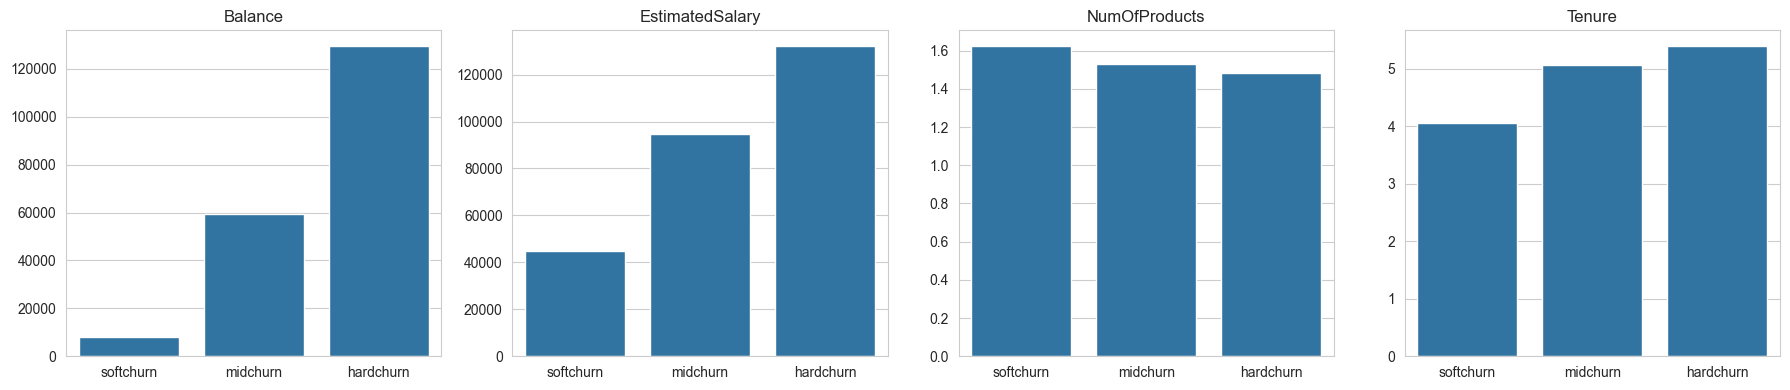

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ['Balance', 'EstimatedSalary', 'NumOfProducts', 'Tenure']):
    sns.barplot(x=order, y=summary[col].values, ax=ax, order=order)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('../reports/figures/eda/churntype_validation.png', dpi=120)
plt.show()

**Resultado:** ver valores impresos arriba. Si las cuatro medias crecen de forma monotona de `softchurn` a `hardchurn`, la regla es internamente consistente (cada banda de valor superior tiene, en promedio, mas balance, mas salario, mas productos y mas antiguedad que la anterior).

## 7. Chequeo de independencia respecto a `Exited`

Este chequeo es solo diagnostico (para confirmar que no hemos construido, sin querer, un proxy de `Exited`). No se usa `Exited` en el calculo de `ChurnType`, solo lo comparamos a posteriori.

In [14]:
print(df.groupby('ChurnType')['Exited'].mean().loc[order])

ChurnType
softchurn    0.152969
midchurn     0.183700
hardchurn    0.252606
Name: Exited, dtype: float64


**Resultado (version final con bandas fijas):** softchurn 15.3%, midchurn 18.4%, hardchurn 25.3% de tasa de `Exited`. Hay una relacion suave y monotona creciente, lo cual es razonable: clientes de mayor valor (mas balance, mas antiguedad) tienden a tener perfiles algo distintos de riesgo. Lo importante es que la diferencia es moderada (15-25 puntos, no 5% vs 90%) y que `ChurnType` no se ha calculado usando `Exited` en ningun momento — la relacion observada es una consecuencia indirecta y esperable, no una fuga de informacion. Se re-evaluara en cuando evalemos el modelo si `ChurnType`/`value_score` aportan señal incremental como feature de XGBoost.

## 8. Alternativas consideradas (y por que no se eligieron, de momento)

1. **Umbrales monetarios fijos** (ej. `Balance > 100.000 -> hardchurn`): mas simple de explicar en una frase, pero arbitrario si no viene de un analisis actuarial real del banco, y no se adapta si la composicion de la cartera cambia. Podria adoptarse en produccion si el banco ya tiene esos umbrales definidos por otra area (riesgos, finanzas).
2. **Arbol de decision de negocio** (reglas anidadas tipo 'si Balance > X y NumOfProducts >= 2 entonces...'): mas expresivo para capturar interacciones, pero mas complejo de mantener y de justificar los cortes.
3. **Clustering no supervisado (K-means)** sobre las variables de valor: mas 'data-driven', pero los clusters resultantes no tienen garantizada una interpretacion ordinal limpia (soft < mid < hard) y son mas dificiles de explicar a negocio.
4. **Customer Lifetime Value (CLV) explicito**: la opcion mas rigurosa a nivel financiero (descontar flujos futuros esperados), pero requeriria datos que no tenemos en este dataset (historico de ingresos por cliente, margenes por producto, tasas de descuento). Se documenta como mejora futura en el README.

Nos quedamos con el **scoring ponderado por percentiles + terciles** por ser el mejor equilibrio entre explicabilidad, robustez estadistica y viabilidad con los datos disponibles.

## 9. Conclusion

- `ChurnType` se calcula solo con `Balance`, `EstimatedSalary`, `NumOfProducts`, `Tenure` (ponderadas 0.40/0.30/0.20/0.10).
- **Version final:** cada variable se banda en 0.25/0.50/0.75/1.0 segun cortes de negocio fijos (no percentiles), y `value_score` se clasifica con umbrales absolutos: `<0.4` softchurn, `[0.4, 0.6]` midchurn, `>0.6` hardchurn.
- Distribucion resultante: ~16.7% softchurn, ~46.9% midchurn, ~36.5% hardchurn (no balanceada, y no tiene por que estarlo: refleja la composicion real de valor de la cartera segun las bandas de negocio).
- Mapeo a EUR: 500 / 1.000 / 2.000.
- No usa `Exited` en ningun momento en su calculo; se observa una relacion suave y monotona con `Exited` a posteriori (esperable, no indica leakage).
- Pendiente: evaluar si `ChurnType` (o `value_score`) aporta señal incremental como feature de XGBoost, via feature importance / SHAP.